In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import netCDF4 as nc
from scipy.stats import linregress

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_core_mean

styles = {
    'AE': {'line': 'darkred', 'fill': 'red'},
    'CE': {'line': 'navy',    'fill': 'blue'}
}


In [15]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_tilt_ameda.pkl')
df_ameda = df_ameda.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_ameda


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,split2,merge,merge2,shapes2,interaction,interaction2,area,deta,TiltDis,TiltDir
0,1,1462,AE,159.538447,-33.372496,256,186,895.838095,919.548973,0.000010,...,NaN,NaN,NaN,NaN,NaN,NaN,46653.514371,-0.000011,NaN,NaN
1,1,1463,AE,159.686966,-33.160751,257,192,903.002279,946.853133,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4313.383226,-0.000164,NaN,NaN
2,1,1464,AE,159.649836,-33.118402,256,192,898.424872,950.150915,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4336.799061,-0.000070,NaN,NaN
3,1,1465,AE,159.686966,-33.118402,257,193,901.765461,951.353349,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,6480.379311,-0.000047,16.147158,80.585819
4,1,1466,AE,159.575577,-32.949006,254,196,886.770848,965.738198,0.000020,...,NaN,NaN,NaN,NaN,NaN,NaN,6101.676103,-0.000401,19.455358,63.680275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,125,252,327.112431,1244.142958,-0.000014,...,NaN,NaN,NaN,NaN,NaN,NaN,1147.953129,0.000186,8.196140,194.802223
104566,3519,10647,CE,154.860106,-29.052897,127,247,331.141370,1220.843200,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,8038.013328,0.000109,43.813072,358.254256
104567,3519,10648,CE,154.897235,-29.222293,130,244,340.502393,1204.416117,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,9866.414298,0.000095,NaN,NaN
104568,3519,10649,CE,154.377420,-28.417662,100,257,264.105244,1270.945276,-0.000010,...,NaN,NaN,NaN,NaN,NaN,NaN,5581.424065,0.000003,NaN,NaN


In [4]:
def panel(ax, xcol, xlabel, legend_key, xlim=None, split=None, reg_lo_override=None,
          reg_hi_override=None, scatter=False, xlim_flag=False, ncol=2, df_data=df_ameda, zonal_TD=False, meridional_TD=False):
    df_all = df_data.dropna(subset=[xcol])
    x_min, x_max = df_all[xcol].min(), df_all[xcol].max()

    nbins = 30
    bins = np.unique(np.quantile(df_all[xcol], np.linspace(0, 1, nbins + 1)))
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    for cyc in ['AE', 'CE']:
        if zonal_TD:
            dfm = df_data[df_data.Cyc == cyc].dropna(subset=[xcol, 'TiltDis_x'])
        elif meridional_TD:
            dfm = df_data[df_data.Cyc == cyc].dropna(subset=[xcol, 'TiltDis_y'])
        else:
            dfm = df_data[df_data.Cyc == cyc].dropna(subset=[xcol, 'TiltDis'])
        if len(dfm) == 0:
            continue
        xval = dfm[xcol].values
        if zonal_TD:
            tilt = dfm['TiltDis_x'].values
        elif meridional_TD:
            tilt = dfm['TiltDis_y'].values
        else:
            tilt = dfm['TiltDis'].values

        mask = (xval >= x_min) & (xval <= x_max)
        xval, tilt = xval[mask], tilt[mask]

        d = np.digitize(xval, bins)
        med = [np.nanmedian(tilt[d == i]) for i in range(1, len(bins))]
        q25 = [np.nanquantile(tilt[d == i], .25) for i in range(1, len(bins))]
        q75 = [np.nanquantile(tilt[d == i], .75) for i in range(1, len(bins))]

        if scatter:
            ax.scatter(xval, tilt, s=1, alpha=0.08, color=styles[cyc]['fill'])

        ax.plot(bin_centers, med, lw=3, color=styles[cyc]['line'], alpha=.6)
        ax.fill_between(bin_centers, q25, q75, color=styles[cyc]['fill'], alpha=0.10)

        if split is None:
            lo, hi = np.nanpercentile(xval, [10, 90])
            mask = (xval >= lo) & (xval <= hi)
            m, c, *_ = linregress(xval[mask], tilt[mask])
            xf = np.linspace(lo, hi, 200)
            ax.plot(
                xf, m*xf + c, '--', lw=3, color=styles[cyc]['fill'],
                label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c<0 else "$+$"} {abs(c):.3g}'
            )
        else:
            lo, hi = np.nanpercentile(xval, [10, 90])

            hi2 = reg_hi_override if reg_hi_override is not None else hi
            lo2 = reg_lo_override if reg_lo_override is not None else lo

            for l, (a, b) in enumerate(zip([lo2, split], [split, hi2])):
                mask = (xval >= a) & (xval <= b)
                if mask.sum() > 2:
                    m, c, *_ = linregress(xval[mask], tilt[mask])
                    xf = np.linspace(a, b, 200)
                    ax.plot(
                        xf, m*xf + c,
                        ':' if l == 0 else '--',
                        lw=3,
                        color=styles[cyc]['fill'],
                        label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c<0 else "$+$"} {abs(c):.3g}'
                    )

    if xlim is None:
        ax.set_xlim(*np.nanpercentile(df_data[xcol], [10, 90]))
    else:
        ax.set_xlim(*xlim)

    if xlim_flag:
        ax.set_xlim(bin_centers.min(), bin_centers.max())

    ax.legend(loc='upper left', ncol=ncol)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

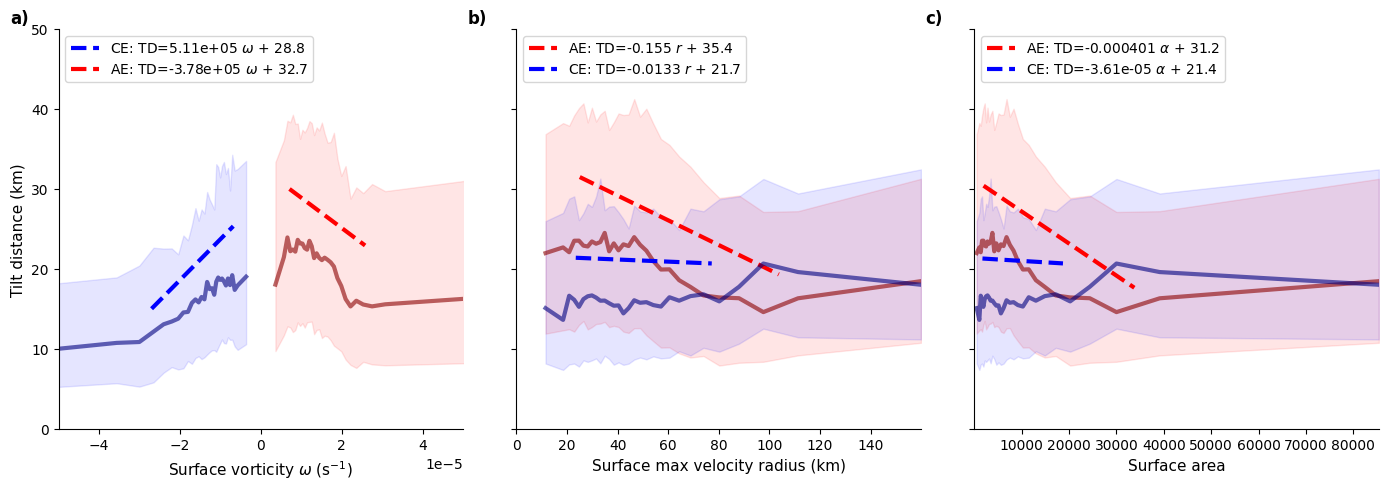

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey=True, constrained_layout=False)

panel(
    axs[0],
    'w',
    r'',
    r'$\omega$',
    xlim_flag=False,
    scatter=False,
    xlim=(-4e-5, 4e-5),
    ncol=1,
    df_data=df_ameda[df_ameda.Cyc=='CE'].copy()
)
panel(
    axs[0],
    'w',
    r'Surface vorticity $\omega$ (s$^{-1}$)',
    r'$\omega$',
    xlim_flag=False,
    scatter=False,
    xlim=(-5e-5, 5e-5),
    ncol=1,
    df_data=df_ameda[df_ameda.Cyc=='AE'].copy()
)
axs[0].set_ylabel('Tilt distance (km)', fontsize=11)
axs[0].text(-0.12, 1.05, 'a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

panel(
    axs[1],
    'rmax',
    'Surface max velocity radius (km)',
    r'$r$',
    xlim_flag=True,
    scatter=False,
    # xlim=(40, 160),
    ncol=1
)
axs[1].text(-0.12, 1.05, 'b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[1].set_xlim(0, None)

panel(
    axs[2],
    'area',
    r'Surface area',
    r'$\alpha$',
    xlim_flag=True,
    scatter=False,
    xlim=(0, None),
    ncol=1
)
axs[2].text(-0.12, 1.05, 'c)', transform=axs[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[2].set_ylim(0, 50)
axs[2].set_xlim(1, None)
plt.tight_layout()
plt.show()


/scratch/pbs.8130668.kman.restech.unsw.edu.au/ipykernel_77855/3234182958.py:44: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  axs[2].set_xlim(1, None)


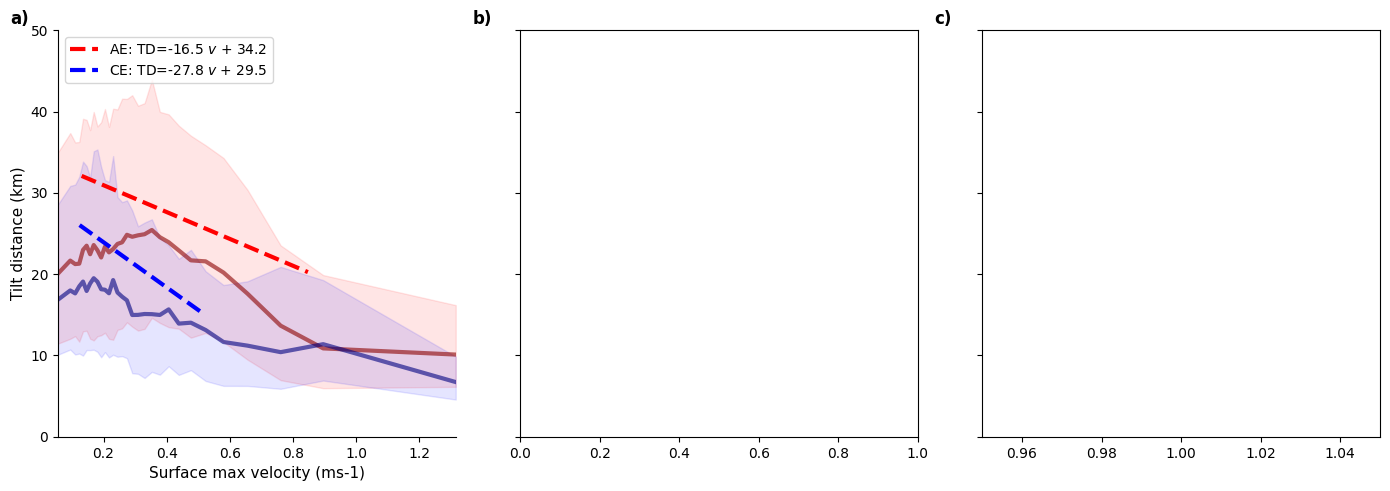

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey=True, constrained_layout=False)

panel(
    axs[0],
    'velmax',
    'Surface max velocity (ms-1)',
    r'$v$',
    xlim_flag=True,
    scatter=False,
    # xlim=(40, 160),
    ncol=1
)
axs[0].set_ylabel('Tilt distance (km)', fontsize=11)
axs[0].text(-0.12, 1.05, 'a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

# panel(
#     axs[1],
#     'rmax',
#     'Surface core radius $R_c$ (km)',
#     r'$R$',
#     xlim_flag=True,
#     scatter=False,
#     # xlim=(40, 160),
#     ncol=1
# )
axs[1].text(-0.12, 1.05, 'b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[1].set_xlim(0, None)

# panel(
#     axs[2],
#     'area',
#     r'Surface area',
#     r'$\alpha$',
#     xlim_flag=True,
#     scatter=False,
#     xlim=(0, None),
#     ncol=1
# )
axs[2].text(-0.12, 1.05, 'c)', transform=axs[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[2].set_ylim(0, 50)
axs[2].set_xlim(1, None)
plt.tight_layout()
plt.show()


In [7]:
# Nbar
df_ameda = compute_core_mean(
    df_ameda,
    X_grid, Y_grid,
    mask_rho,
    base_path="/srv/scratch/z5297792/Climatology/N2s/Nbars_300m_depth",
    varname="Nbar",
    colname="Nbar",
    circle_region_flag=True
)


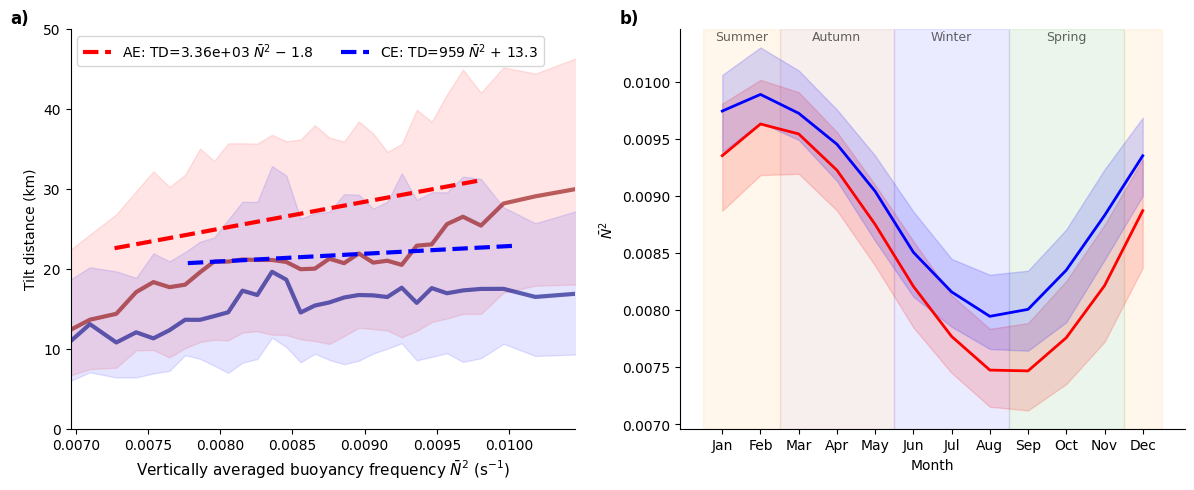

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# -------------------
# LEFT: PANEL (Nbar vs Tilt)
# -------------------
panel(
    axs[0],
    'Nbar',
    r'Vertically averaged buoyancy frequency $\bar{N}^2$ (s$^{-1}$)',
    r'$\bar{N}^2$',
    xlim_flag=False,
    scatter=False,
    xlim=(.007, .0105),
    ncol=2,
    df_data=df_ameda
)
axs[0].set_ylabel('Tilt distance (km)')
axs[0].set_ylim(0, 50)


# -------------------
# RIGHT: MONTHLY PANEL
# -------------------
df_AE = df_ameda[df_ameda.Cyc == 'AE'].copy()
df_CE = df_ameda[df_ameda.Cyc == 'CE'].copy()

for label, df, c in [('AE', df_AE, 'r'), ('CE', df_CE, 'b')]:
    df_ = df.copy()
    df_['Month'] = df_.Date.dt.month

    g = df_.groupby('Month').Nbar
    med = g.median()
    q25 = g.quantile(0.25)
    q75 = g.quantile(0.75)

    axs[1].plot(med.index, med.values, lw=2, color=c, label=label)
    axs[1].fill_between(med.index, q25, q75, color=c, alpha=0.15)

# -------------------
# SEASON SHADING
# -------------------
season_spans = [
    (12-0.5, 12.5, 'Summer'),   # Dec (wrap handled below)
    (0.5, 2.5, 'Summer'),       # Jan–Feb
    (2.5, 5.5, 'Autumn'),
    (5.5, 8.5, 'Winter'),
    (8.5, 11.5, 'Spring')
]

season_colors = {
    'Summer': 'orange',
    'Autumn': 'brown',
    'Winter': 'blue',
    'Spring': 'green'
}

for start, end, season in season_spans:
    axs[1].axvspan(start, end, color=season_colors[season], alpha=0.08, zorder=-1)

season_centers = {
    'Summer': 1.5,
    'Autumn': 4,
    'Winter': 7,
    'Spring': 10
}

for s, x in season_centers.items():
    axs[1].text(x, 0.01045, s,
                ha='center', va='top', fontsize=9, alpha=0.6)

axs[1].set_xticks(range(1, 13))
axs[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])
axs[1].set_xlabel('Month')
axs[1].set_ylabel(r'$\bar{N}^2$')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

axs[0].text(-0.12, 1.05, 'a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[1].text(-0.12, 1.05, 'b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

axs[0].set_xlim(axs[1].get_ylim())

plt.subplots_adjust(wspace=0.001)
plt.tight_layout()


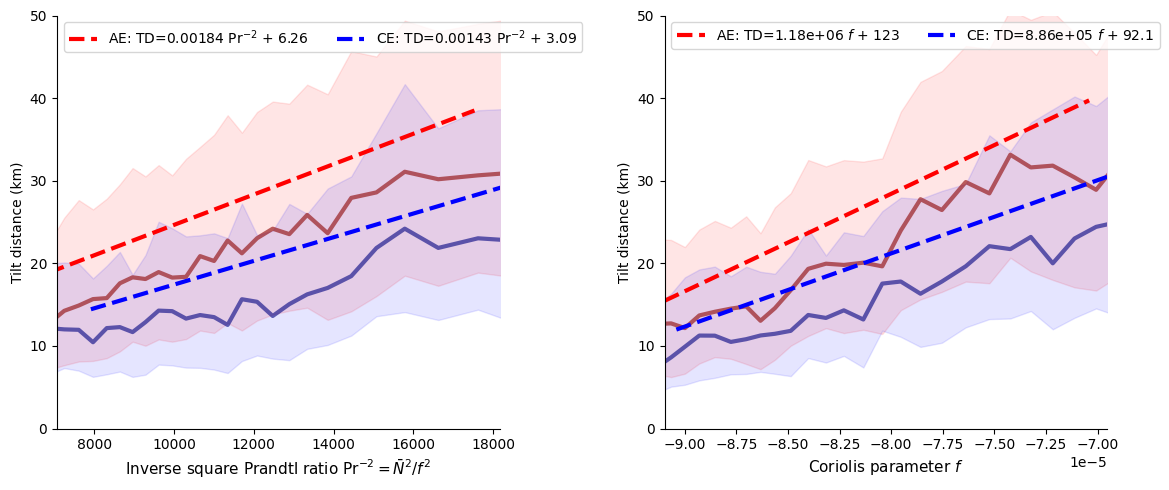

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# -------------------
# LEFT: PANEL (Nbar vs Tilt)
# -------------------
df_ameda['Pr'] = df_ameda.Nbar**2 / f[df_ameda.ic, df_ameda.jc]**2
panel(
    axs[0],
    'Pr',
    r'Inverse square Prandtl ratio Pr$^{-2}=\bar{N}^2/f^2$',
    r'Pr$^{-2}$',
    xlim_flag=False,
    scatter=False,
    # xlim=(.007, .0105),
    ncol=2,
    df_data=df_ameda
)
axs[0].set_ylabel('Tilt distance (km)')
axs[0].set_ylim(0, 50)

df_ameda['f'] = f[df_ameda.ic, df_ameda.jc]
panel(
    axs[1],
    'f',
    r'Coriolis parameter $f$',
    r'$f$',
    xlim_flag=False,
    scatter=False,
    # xlim=(.007, .0105),
    ncol=2,
    df_data=df_ameda
)
axs[1].set_ylabel('Tilt distance (km)')
axs[1].set_ylim(0, 50)


plt.tight_layout()
